In [1]:
import os
from pathlib import Path

baselines_fleetsdeg = 'baselines_fleetsdeg' 
testfolder = 'Sims'

if not os.path.exists(testfolder):
    os.makedirs(testfolder)

if not os.path.exists(baselines_fleetsdeg):
    os.makedirs(baselines_fleetsdeg)

In [2]:
import PV_ICE

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({'font.size': 14})
plt.rcParams['figure.figsize'] = (12, 5)

In [4]:
# This information helps with debugging and getting support :)
import sys, platform
from datetime import date

print("DATE: ", date.today())
print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("Pandas version ", pd.__version__)
print("PV_ICE version ", PV_ICE.__version__)


DATE:  2025-11-25
Working on a  Windows 11
Python version  3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Pandas version  2.2.3
PV_ICE version  0.2.1.dev686+gfb6f99a63


In [5]:
US_base_dir = r'C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\baselines'
US_baseline_file = 'baseline_modules_mass_US_Si.csv' # 'baseline_modules_mass_US_updatedT50T90.csv'
US_baseline_file_CdTe = 'baseline_modules_mass_US_CdTe.csv'
degradation_file = r'PVFleets_Degradation_Data.csv' # same folder

out_dir = 'baselines_fleetsdeg'

In [6]:
# SI First
baseline_path = os.path.join(US_base_dir, US_baseline_file)

# --- Read baseline ---
df_raw = pd.read_csv(baseline_path)
columns_order = df_raw.columns.tolist()
units_row = df_raw.iloc[0:1].copy()          # exact units row as in source

deg = pd.read_csv(degradation_file, sep=None, engine='python')


capacity_col  = 'new_Installed_Capacity_[MW]'
year_col  = 'year'

# Normalize column names (strip spaces, unify)
deg.columns = [c.strip() for c in deg.columns]
# Handle common header variants
rename_map = {}
for c in deg.columns:
    if 'Degradation' in c and 'Rate' in c:
        rename_map[c] = 'deg_rate'
    if '%' in c and ('Cohort' in c or 'cohort' in c):
        rename_map[c] = 'cohort_pct'
deg = deg.rename(columns=rename_map)

# Clean types
deg['deg_rate'] = pd.to_numeric(deg['deg_rate'], errors='coerce')
deg['cohort_pct'] = pd.to_numeric(deg['cohort_pct'], errors='coerce')
deg = deg.dropna(subset=['deg_rate', 'cohort_pct'])

# Work on a cleaned copy for math
df_base = df_raw.iloc[1:].copy()

# Coerce numerics to drop non-numeric rows (like the units row) for calculations
df_base[year_col] = pd.to_numeric(df_base[year_col], errors='coerce')
df_base[capacity_col] = pd.to_numeric(df_base[capacity_col], errors='coerce')

# --- Helper: prepend units row and enforce original column order ---
def finalize_with_units(df_calc: pd.DataFrame) -> pd.DataFrame:
    # Reorder to original columns (plus any new ones we ensured in units_row)
    df_calc = df_calc.reindex(columns=columns_order)
    # Align units row to same columns
    units_aligned = units_row.reindex(columns=columns_order)
    # Prepend units row exactly as it appeared
    out = pd.concat([units_aligned, df_calc], ignore_index=True)
    return out

year_num = pd.to_numeric(df_raw[year_col], errors='coerce')
mask_startyear = year_num >= 2017

saved_files = []

for _, row in deg.iterrows():
    rate = float(row['deg_rate'])        # typically negative in PV Fleets (e.g., -2.0 %/yr)
    pct = float(row['cohort_pct'])       # in percent (e.g., 5.0 means 5%)

    df_cohort = df_base.copy()

    # Scale the installed capacity by the cohort share
    df_cohort[capacity_col] = df_cohort[capacity_col] * (pct / 100.0)

    # Set mod_degradation to the positive number (e.g., 2.0 for -2.0), per your example
    df_cohort.loc[mask_startyear, 'mod_degradation'] = abs(rate)

    # Save per-cohort file
    base_name = "baseline_modules_mass_Si"   # no .csv, just the stem
    out_name = f"{base_name}__cohort_{pct:0.2f}pct__deg_{abs(rate):0.1f}.csv"
    df_out = finalize_with_units(df_cohort)
    out_path = os.path.join(out_dir, out_name)
    df_out.to_csv(out_path, index=False)
    saved_files.append(Path(out_path).stem)

saved_files

['baseline_modules_mass_Si__cohort_0.18pct__deg_5.2',
 'baseline_modules_mass_Si__cohort_0.59pct__deg_4.2',
 'baseline_modules_mass_Si__cohort_1.04pct__deg_3.4',
 'baseline_modules_mass_Si__cohort_0.45pct__deg_3.2',
 'baseline_modules_mass_Si__cohort_0.57pct__deg_3.0',
 'baseline_modules_mass_Si__cohort_0.73pct__deg_2.8',
 'baseline_modules_mass_Si__cohort_1.12pct__deg_2.6',
 'baseline_modules_mass_Si__cohort_1.36pct__deg_2.4',
 'baseline_modules_mass_Si__cohort_2.34pct__deg_2.2',
 'baseline_modules_mass_Si__cohort_3.50pct__deg_2.0',
 'baseline_modules_mass_Si__cohort_4.70pct__deg_1.8',
 'baseline_modules_mass_Si__cohort_5.37pct__deg_1.6',
 'baseline_modules_mass_Si__cohort_6.90pct__deg_1.4',
 'baseline_modules_mass_Si__cohort_8.51pct__deg_1.2',
 'baseline_modules_mass_Si__cohort_10.22pct__deg_1.0',
 'baseline_modules_mass_Si__cohort_11.62pct__deg_0.8',
 'baseline_modules_mass_Si__cohort_12.30pct__deg_0.6',
 'baseline_modules_mass_Si__cohort_10.06pct__deg_0.4',
 'baseline_modules_mass_

In [7]:
# SI First
baseline_path = os.path.join(US_base_dir, US_baseline_file_CdTe)

# --- Read baseline ---
df_raw = pd.read_csv(baseline_path)
columns_order = df_raw.columns.tolist()
units_row = df_raw.iloc[0:1].copy()          # exact units row as in source

deg = pd.read_csv(degradation_file, sep=None, engine='python')


capacity_col  = 'new_Installed_Capacity_[MW]'
year_col  = 'year'

# Normalize column names (strip spaces, unify)
deg.columns = [c.strip() for c in deg.columns]
# Handle common header variants
rename_map = {}
for c in deg.columns:
    if 'Degradation' in c and 'Rate' in c:
        rename_map[c] = 'deg_rate'
    if '%' in c and ('Cohort' in c or 'cohort' in c):
        rename_map[c] = 'cohort_pct'
deg = deg.rename(columns=rename_map)

# Clean types
deg['deg_rate'] = pd.to_numeric(deg['deg_rate'], errors='coerce')
deg['cohort_pct'] = pd.to_numeric(deg['cohort_pct'], errors='coerce')
deg = deg.dropna(subset=['deg_rate', 'cohort_pct'])

# Work on a cleaned copy for math
df_base = df_raw.iloc[1:].copy()

# Coerce numerics to drop non-numeric rows (like the units row) for calculations
df_base[year_col] = pd.to_numeric(df_base[year_col], errors='coerce')
df_base[capacity_col] = pd.to_numeric(df_base[capacity_col], errors='coerce')

# --- Helper: prepend units row and enforce original column order ---
def finalize_with_units(df_calc: pd.DataFrame) -> pd.DataFrame:
    # Reorder to original columns (plus any new ones we ensured in units_row)
    df_calc = df_calc.reindex(columns=columns_order)
    # Align units row to same columns
    units_aligned = units_row.reindex(columns=columns_order)
    # Prepend units row exactly as it appeared
    out = pd.concat([units_aligned, df_calc], ignore_index=True)
    return out

year_num = pd.to_numeric(df_raw[year_col], errors='coerce')
mask_startyear = year_num >= 2017

saved_files_CdTE = []

for _, row in deg.iterrows():
    rate = float(row['deg_rate'])        # typically negative in PV Fleets (e.g., -2.0 %/yr)
    pct = float(row['cohort_pct'])       # in percent (e.g., 5.0 means 5%)

    df_cohort = df_base.copy()

    # Scale the installed capacity by the cohort share
    df_cohort[capacity_col] = df_cohort[capacity_col] * (pct / 100.0)

    # Set mod_degradation to the positive number (e.g., 2.0 for -2.0), per your example
    df_cohort.loc[mask_startyear, 'mod_degradation'] = abs(rate)

    # Save per-cohort file
    base_name = "baseline_modules_mass_CdTe"   # no .csv, just the stem
    out_name = f"{base_name}__cohort_{pct:0.2f}pct__deg_{abs(rate):0.1f}.csv"
    df_out = finalize_with_units(df_cohort)
    out_path = os.path.join(out_dir, out_name)
    df_out.to_csv(out_path, index=False)
    saved_files_CdTE.append(Path(out_path).stem)

saved_files_CdTE

['baseline_modules_mass_CdTe__cohort_0.18pct__deg_5.2',
 'baseline_modules_mass_CdTe__cohort_0.59pct__deg_4.2',
 'baseline_modules_mass_CdTe__cohort_1.04pct__deg_3.4',
 'baseline_modules_mass_CdTe__cohort_0.45pct__deg_3.2',
 'baseline_modules_mass_CdTe__cohort_0.57pct__deg_3.0',
 'baseline_modules_mass_CdTe__cohort_0.73pct__deg_2.8',
 'baseline_modules_mass_CdTe__cohort_1.12pct__deg_2.6',
 'baseline_modules_mass_CdTe__cohort_1.36pct__deg_2.4',
 'baseline_modules_mass_CdTe__cohort_2.34pct__deg_2.2',
 'baseline_modules_mass_CdTe__cohort_3.50pct__deg_2.0',
 'baseline_modules_mass_CdTe__cohort_4.70pct__deg_1.8',
 'baseline_modules_mass_CdTe__cohort_5.37pct__deg_1.6',
 'baseline_modules_mass_CdTe__cohort_6.90pct__deg_1.4',
 'baseline_modules_mass_CdTe__cohort_8.51pct__deg_1.2',
 'baseline_modules_mass_CdTe__cohort_10.22pct__deg_1.0',
 'baseline_modules_mass_CdTe__cohort_11.62pct__deg_0.8',
 'baseline_modules_mass_CdTe__cohort_12.30pct__deg_0.6',
 'baseline_modules_mass_CdTe__cohort_10.06pct

In [8]:
out_dir

'baselines_fleetsdeg'

In [9]:
import re
deg_parts = [re.search(r'(deg_[^_]+)$', n).group(1) for n in saved_files if re.search(r'(deg_[^_]+)$', n)]


In [10]:
r1 = PV_ICE.Simulation(name='Sim1', path=testfolder)

path = Sims
Baseline folder directed to default:  C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\baselines


In [11]:
r1.createScenario(name='base_Si', massmodulefile='baseline_modules_mass_US_Si.csv', energymodulefile='baseline_modules_energy.csv')
r1.scenario['base_Si'].addMaterials(['glass', 'silicon', 'silver', 'copper', 'aluminium_frames', 'encapsulant'])


Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files for:  encapsulant


In [12]:
r1.createScenario(name='base_CdTe', massmodulefile='baseline_modules_mass_US_CdTe.csv', energymodulefile='baseline_modules_energy.csv')
r1.scenario['base_CdTe'].addMaterials(['cadmium', 'tellurium', 'glass_cdte', 'aluminium_frames_cdte', 'encapsulant_cdte', 'copper_cdte'])


Adding Mass AND Energy files for:  cadmium
Adding Mass AND Energy files for:  tellurium
Adding Mass files for:  glass_cdte
Adding Mass files for:  aluminium_frames_cdte
Adding Mass files for:  encapsulant_cdte
Adding Mass files for:  copper_cdte


In [13]:
for ii in range(0, len(saved_files)):
    foopath = r'C:\Users\sayala\Documents\GitHub\PV_ICE\Studies\PVWaste_for_EPRI_US_National_PVFleetsDg_Si&CdTe_Nov25\baselines_fleetsdeg'
    ii_csv = saved_files[ii] + '.csv'
    ii_csv_path =  os.path.join(foopath, ii_csv)
    ii_name = 'Si_'+deg_parts[ii]
    r1.createScenario(name=ii_name, massmodulefile=ii_csv_path, energymodulefile='baseline_modules_energy.csv')
    r1.scenario[ii_name].addMaterials(['glass', 'silicon', 'silver', 'copper', 'aluminium_frames', 'encapsulant'])


Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files for:  encapsulant
Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files for:  encapsulant
Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files for:  encapsulant
Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files fo

In [14]:
for ii in range(0, len(saved_files)):
    foopath = r'C:\Users\sayala\Documents\GitHub\PV_ICE\Studies\PVWaste_for_EPRI_US_National_PVFleetsDg_Si&CdTe_Nov25\baselines_fleetsdeg'
    ii_csv = saved_files[ii] + '.csv'
    ii_csv_path =  os.path.join(foopath, ii_csv)
    ii_name = 'CdTe_'+deg_parts[ii]
    r1.createScenario(name=ii_name, massmodulefile=ii_csv_path, energymodulefile='baseline_modules_energy.csv')
    r1.scenario[ii_name].addMaterials(['cadmium', 'tellurium', 'glass_cdte', 'aluminium_frames_cdte', 'encapsulant_cdte', 'copper_cdte'])


Adding Mass AND Energy files for:  cadmium
Adding Mass AND Energy files for:  tellurium
Adding Mass files for:  glass_cdte
Adding Mass files for:  aluminium_frames_cdte
Adding Mass files for:  encapsulant_cdte
Adding Mass files for:  copper_cdte
Adding Mass AND Energy files for:  cadmium
Adding Mass AND Energy files for:  tellurium
Adding Mass files for:  glass_cdte
Adding Mass files for:  aluminium_frames_cdte
Adding Mass files for:  encapsulant_cdte
Adding Mass files for:  copper_cdte
Adding Mass AND Energy files for:  cadmium
Adding Mass AND Energy files for:  tellurium
Adding Mass files for:  glass_cdte
Adding Mass files for:  aluminium_frames_cdte
Adding Mass files for:  encapsulant_cdte
Adding Mass files for:  copper_cdte
Adding Mass AND Energy files for:  cadmium
Adding Mass AND Energy files for:  tellurium
Adding Mass files for:  glass_cdte
Adding Mass files for:  aluminium_frames_cdte
Adding Mass files for:  encapsulant_cdte
Adding Mass files for:  copper_cdte
Adding Mass AND 

In [15]:
r1.trim_Years(startYear=1995, endYear=2026)


Trimming and extending  base_Si
base_Si glass : Data trimmed for Energy, years now encompass  1995  to  2026
base_Si silicon : Data trimmed for Energy, years now encompass  1995  to  2026
base_Si silver : Data trimmed for Energy, years now encompass  1995  to  2026
base_Si copper : Data trimmed for Energy, years now encompass  1995  to  2026
base_Si aluminium_frames : Data trimmed for Energy, years now encompass  1995  to  2026
base_Si encapsulant : Data trimmed for Energy, years now encompass  1995  to  2026
base_Si encapsulant : Data trimmed for Mass, years now encompass  1995  to  2026
Trimming and extending  base_CdTe
base_CdTe cadmium : Data trimmed for Energy, years now encompass  1995  to  2026
base_CdTe tellurium : Data trimmed for Energy, years now encompass  1995  to  2026
No material energy data loaded.
No material energy data loaded.
No material energy data loaded.
No material energy data loaded.
base_CdTe copper_cdte : Data trimmed for Mass, years now encompass  1995  to  

In [16]:
r1.calculateFlows()

>>>> Calculating Material Flows <<<<

Working on Scenario:  base_Si
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> Working on Material :  encapsulant
Working on Scenario:  base_CdTe
********************
Finished Area+Power Generation Calculations
==> Working on Material :  cadmium
==> Working on Material :  tellurium
==> Working on Material :  glass_cdte
==> Working on Material :  aluminium_frames_cdte


C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:1432: RuntimeWarning: invalid value encountered in scalar subtract
  recycledsurplus = ( dm['mat_MFG_Recycled_HQ_into_MFG'].loc[rr] + #mfg scrap in that year


==> Working on Material :  encapsulant_cdte
==> Working on Material :  copper_cdte
Working on Scenario:  Si_deg_5.2
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> Working on Material :  encapsulant
Working on Scenario:  Si_deg_4.2
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> Working on Material :  encapsulant
Working on Scenario:  Si_deg_3.4
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> W

C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:1432: RuntimeWarning: invalid value encountered in scalar subtract
  recycledsurplus = ( dm['mat_MFG_Recycled_HQ_into_MFG'].loc[rr] + #mfg scrap in that year


==> Working on Material :  glass_cdte
==> Working on Material :  aluminium_frames_cdte
==> Working on Material :  encapsulant_cdte
==> Working on Material :  copper_cdte
Working on Scenario:  CdTe_deg_4.2
********************
Finished Area+Power Generation Calculations
==> Working on Material :  cadmium
==> Working on Material :  tellurium


...

==> Working on Material :  aluminium_frames_cdte
==> Working on Material :  encapsulant_cdte
==> Working on Material :  copper_cdte
Working on Scenario:  CdTe_deg_0.4
********************
Finished Area+Power Generation Calculations
==> Working on Material :  cadmium
==> Working on Material :  tellurium


C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:1432: RuntimeWarning: invalid value encountered in scalar subtract
  recycledsurplus = ( dm['mat_MFG_Recycled_HQ_into_MFG'].loc[rr] + #mfg scrap in that year


==> Working on Material :  glass_cdte
==> Working on Material :  aluminium_frames_cdte
==> Working on Material :  encapsulant_cdte
==> Working on Material :  copper_cdte
Working on Scenario:  CdTe_deg_0.2
********************
Finished Area+Power Generation Calculations
==> Working on Material :  cadmium
==> Working on Material :  tellurium


C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:1432: RuntimeWarning: invalid value encountered in scalar subtract
  recycledsurplus = ( dm['mat_MFG_Recycled_HQ_into_MFG'].loc[rr] + #mfg scrap in that year


==> Working on Material :  glass_cdte
==> Working on Material :  aluminium_frames_cdte
==> Working on Material :  encapsulant_cdte
==> Working on Material :  copper_cdte


>>>> Calculating Energy Flows <<<<

Working on Scenario:  base_Si
********************
==> Working on Energy for Material :  glass
==> Working on Energy for Material :  silicon
==> Working on Energy for Material :  silver
==> Working on Energy for Material :  copper
==> Working on Energy for Material :  aluminium_frames
==> Working on Energy for Material :  encapsulant
Working on Scenario:  base_CdTe
********************
==> Working on Energy for Material :  cadmium
==> Working on Energy for Material :  tellurium
==> No energy material found for Material :  glass_cdte . Skipping Energy calculations.
==> No energy material found for Material :  aluminium_frames_cdte . Skipping Energy calculations.
==> No energy material found for Material :  encapsulant_cdte . Skipping Energy calculations.
==> No energy material found

In [17]:
USyearly, UScum = r1.aggregateResults()

C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:2188: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  USyearly[nicekey+'_'+mat+'_'+self.name+'_'+scen] = self.scenario[scen].material[mat].matdataOut_m[keywd]
C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:2188: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  USyearly[nicekey+'_'+mat+'_'+self.name+'_'+scen] = self.scenario[scen].material[mat].matdataOut_m[keywd]
C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:2188: PerformanceWarning: DataFrame is highly fragmente

In [18]:
r1.saveSimulation()

KeyError: 'glass'

In [19]:
UScum.to_csv('Cumulative.csv')
USyearly.to_csv('Yearly.csv')

In [20]:
UScum.keys()[:80]

Index(['VirginStock_glass_Sim1_base_Si_[Tonnes]',
       'VirginStock_silicon_Sim1_base_Si_[Tonnes]',
       'VirginStock_silver_Sim1_base_Si_[Tonnes]',
       'VirginStock_copper_Sim1_base_Si_[Tonnes]',
       'VirginStock_aluminium_frames_Sim1_base_Si_[Tonnes]',
       'VirginStock_encapsulant_Sim1_base_Si_[Tonnes]',
       'VirginStock_Module_Sim1_base_Si_[Tonnes]',
       'WasteAll_glass_Sim1_base_Si_[Tonnes]',
       'WasteAll_silicon_Sim1_base_Si_[Tonnes]',
       'WasteAll_silver_Sim1_base_Si_[Tonnes]',
       'WasteAll_copper_Sim1_base_Si_[Tonnes]',
       'WasteAll_aluminium_frames_Sim1_base_Si_[Tonnes]',
       'WasteAll_encapsulant_Sim1_base_Si_[Tonnes]',
       'WasteAll_Module_Sim1_base_Si_[Tonnes]',
       'WasteEOL_glass_Sim1_base_Si_[Tonnes]',
       'WasteEOL_silicon_Sim1_base_Si_[Tonnes]',
       'WasteEOL_silver_Sim1_base_Si_[Tonnes]',
       'WasteEOL_copper_Sim1_base_Si_[Tonnes]',
       'WasteEOL_aluminium_frames_Sim1_base_Si_[Tonnes]',
       'WasteEOL_encapsulan

# POST PROCESSING

In [21]:
#'WasteEOL_Module_Sim1_base_Si_[Tonnes]'
#'WasteEOL_Module_Sim1_Si_deg_5.2_[Tonnes]'

In [22]:
# 1. identify the deg_* columns
deg_cols = [c for c in UScum.columns if c.startswith("WasteEOL_Module_Sim1_Si_deg_")]

total_col = 'WasteEOL_Module_Sim1_Si_deg_TOTAL_[Tonnes]'

# 2. create a new column with the row-wise sum
UScum[total_col] = UScum[deg_cols].sum(axis=1)

In [23]:
# 1. identify the deg_* columns
deg_cols = [c for c in UScum.columns if c.startswith("WasteEOL_Module_Sim1_CdTe_deg_")]

total_col_CdTe = 'WasteEOL_Module_Sim1_CdTe_deg_TOTAL_[Tonnes]'

# 2. create a new column with the row-wise sum
UScum[total_col_CdTe] = UScum[deg_cols].sum(axis=1)

In [24]:
main_results= UScum[['WasteEOL_Module_Sim1_base_Si_[Tonnes]', 'WasteEOL_Module_Sim1_base_CdTe_[Tonnes]', total_col, total_col_CdTe]]

In [25]:
pwd

'C:\\Users\\sayala\\Documents\\GitHub\\PV_ICE\\Studies\\PVWaste_for_EPRI_US_National_PVFleetsDg_Si&CdTe_Nov25\\Sims'

In [26]:
main_results.to_csv('Main_Results.csv')

## PLOTS 

In [28]:
'Si_'+deg_parts[ii]

'Si_deg_0.2'

Text(0, 0.5, 'Yearly Installed Capacity [MW]')

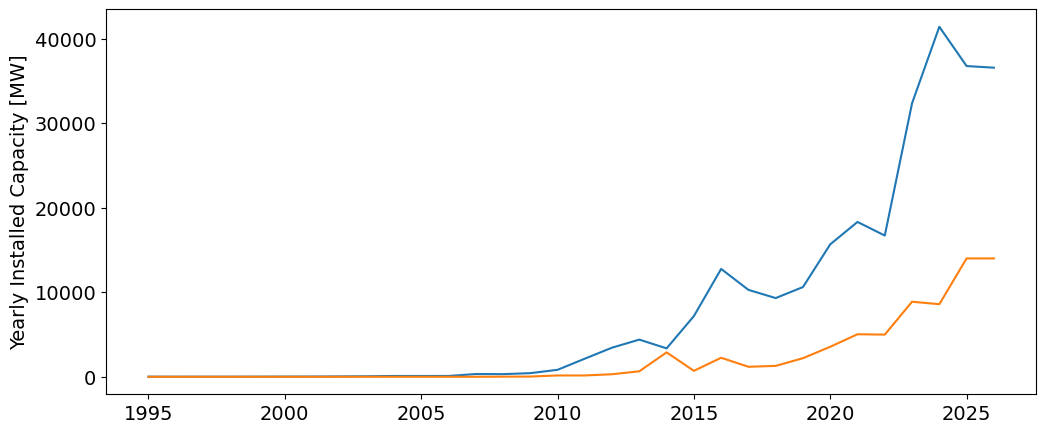

In [29]:
plt.plot(r1.scenario['base_Si'].dataIn_m.year, r1.scenario['base_Si'].dataIn_m['new_Installed_Capacity_[MW]'])
plt.plot(r1.scenario['base_CdTe'].dataIn_m.year, r1.scenario['base_CdTe'].dataIn_m['new_Installed_Capacity_[MW]'])
plt.ylabel('Yearly Installed Capacity [MW]')


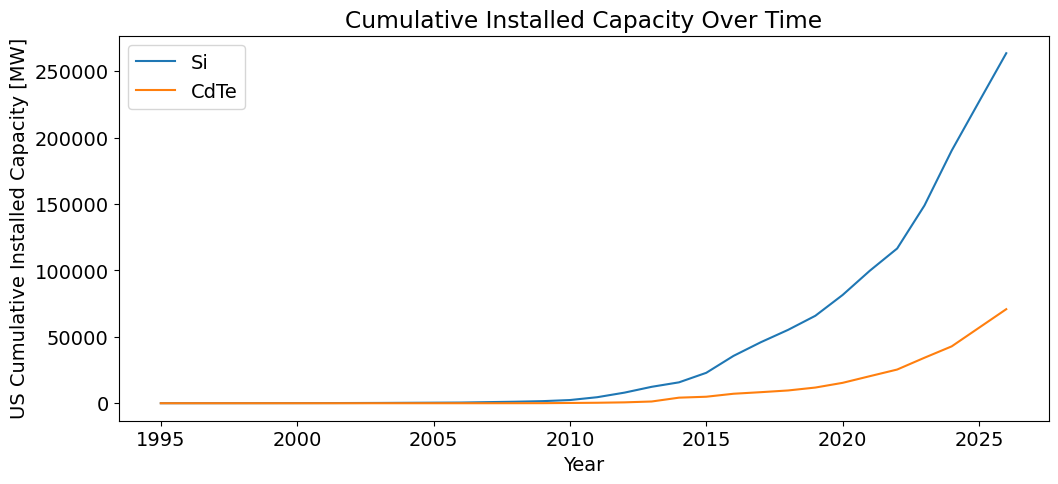

In [30]:
# Cumulative plot
plt.plot(r1.scenario['base_Si'].dataIn_m.year,
         r1.scenario['base_Si'].dataIn_m['new_Installed_Capacity_[MW]'].cumsum(),
         label='Si')

plt.plot(r1.scenario['base_CdTe'].dataIn_m.year,
         r1.scenario['base_CdTe'].dataIn_m['new_Installed_Capacity_[MW]'].cumsum(),
         label='CdTe')

plt.legend()
plt.xlabel('Year')
plt.ylabel('US Cumulative Installed Capacity [MW]')
plt.title('Cumulative Installed Capacity Over Time')
plt.show()
